# Special Extra!! (bài bổ sung)

Nhờ những model tốt nhất hiện nay sinh một SVG.

Lấy cảm hứng từ bài test huyền thoại của Simon Willison: Pelican riding a bike (chim bồ nông đi xe đạp).

Điểm chính: đây là nhiệm vụ rất khác so với tạo ảnh! Model phải mô tả hình bằng đường thẳng và hình khối.

### Notebook này dùng OpenRouter.ai để dễ truy cập các model mới nhất

In [1]:
# imports (nhập thư viện)

from dotenv import load_dotenv
from IPython.display import Markdown, display
from datetime import datetime
import time
from revealer import reveal
from openai import OpenAI
import os
load_dotenv(override=True)

True

In [2]:
# Kiểm tra API key OpenRouter

OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
if OPENROUTER_API_KEY and OPENROUTER_API_KEY.startswith("sk-or-"):
    print("OPENROUTER_API_KEY trông ổn")
else:
    print("OPENROUTER_API_KEY có vẻ chưa đúng")

OPENROUTER_API_KEY trông ổn


In [3]:
# Khởi tạo client OpenRouter (cùng SDK OpenAI, đổi base_url)

openrouter = OpenAI(base_url=OPENROUTER_BASE_URL, api_key=OPENROUTER_API_KEY)

In [4]:
# Đề bài giống video: gấu trúc đi patin đến chỗ làm (giữ tiếng Anh để so sánh với khóa học)

challenge = "a panda rollerblading to work"
prompt = f"Generate an SVG of {challenge}. Respond with the SVG only, no code blocks."
messages = [{"role": "user", "content": prompt}]

In [5]:
# Gọi model, đo thời gian, trả về heading markdown + SVG

def artist(model, effort=None):
    try:
        start = datetime.now()
        response = openrouter.chat.completions.create(model=model, messages=messages, reasoning_effort=effort)
        result = response.choices[0].message.content
        end = datetime.now()
        elapsed = (end - start).total_seconds()
        heading = f"### {model}\n**Thời gian:** {elapsed // 60:.0f} phút {elapsed % 60:.0f} giây\n\n"
    except Exception as e:
        print(f"Model {model} thất bại: {e}")
        heading = f"### {model}\n**Lỗi:** {e}\n\n"
        return heading, None
    return heading, result

In [6]:
# So sánh nhiều model với cùng một prompt

results = [
    artist("openai/gpt-oss-120b"),
    artist("openai/gpt-5-nano", effort="low"),
    artist("deepseek/deepseek-v3.2"),
    artist("moonshotai/kimi-k2-thinking"),
    artist("x-ai/grok-4.1-fast"),
    artist("anthropic/claude-opus-4.5"),
    artist("openai/gpt-5.2", effort="high"),
    artist("google/gemini-3-pro-preview")
]

Model openai/gpt-5-nano thất bại: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 65133. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 65133. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3J3hdSm3pIZQlnOuUPHVK3QhPFT'}
Model moonshotai/kimi-k2-thinking thất bại: Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 100352 tokens, but can on

### openai/gpt-oss-120b
**Thời gian:** 1 phút 55 giây



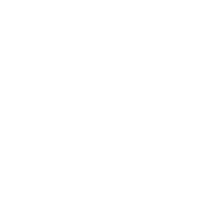

### openai/gpt-5-nano
**Lỗi:** Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 65133. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 65133. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3J3hdSm3pIZQlnOuUPHVK3QhPFT'}



### deepseek/deepseek-v3.2
**Thời gian:** 0 phút 28 giây



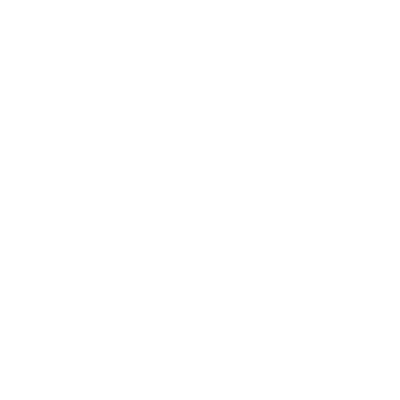

### moonshotai/kimi-k2-thinking
**Lỗi:** Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 100352 tokens, but can only afford 10421. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 131072 tokens, but can only afford 10421. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3J3hdSm3pIZQlnOuUPHVK3QhPFT'}



### x-ai/grok-4.1-fast
**Lỗi:** Error code: 404 - {'error': {'message': 'Grok 4.1 Fast is deprecated. xAI recommends switching to Grok 4.3 (https://openrouter.ai/x-ai/grok-4.3)', 'code': 404}, 'user_id': 'user_3J3hdSm3pIZQlnOuUPHVK3QhPFT'}



### anthropic/claude-opus-4.5
**Lỗi:** Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1040. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1040. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}, {'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1040. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}, {'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1040. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}, {'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 64000 tokens, but can only afford 1040. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3J3hdSm3pIZQlnOuUPHVK3QhPFT'}



### openai/gpt-5.2
**Lỗi:** Error code: 402 - {'error': {'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 1857. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account', 'code': 402, 'metadata': {'limit_source': 'openrouter_credits', 'remedy_hint': 'Add credits at https://openrouter.ai/settings/credits, or lower max_tokens / prompt size to fit your remaining balance.', 'provider_name': None, 'previous_errors': [{'code': 402, 'message': 'This request requires more credits, or fewer max_tokens. You requested up to 65536 tokens, but can only afford 1857. To increase, visit https://openrouter.ai/settings/credits and upgrade to a paid account'}]}}, 'user_id': 'user_3J3hdSm3pIZQlnOuUPHVK3QhPFT'}



### google/gemini-3-pro-preview
**Lỗi:** Error code: 404 - {'error': {'message': 'No endpoints found for google/gemini-3-pro-preview.', 'code': 404}, 'user_id': 'user_3J3hdSm3pIZQlnOuUPHVK3QhPFT'}



In [7]:
# Hiện từng kết quả; sleep 12 giây để xem hiệu ứng vẽ SVG

for result in results:
    try:
        display(Markdown(result[0]))
        reveal(result[1])
        time.sleep(12)
    except Exception as e:
        print(f"Lỗi khi hiển thị kết quả: {e}")

## Week 4 chúng ta sẽ có cách so sánh model khoa học hơn...

nhưng bài này cũng khá vui.